In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ipc.csv', encoding='latin-1', sep=';')

# Convertir v_m_IPC a numérico
df["v_m_IPC"] = df["v_m_IPC"].astype(str).str.replace(',', '.').astype(float)

# Convertir fecha
df["Periodo"] = pd.to_datetime(df["Periodo"].astype(str), format="%Y%m", errors="coerce")
df = df.sort_values("Periodo")

# Filtrar NIVEL GENERAL + Nacional únicamente
df_arg = df[
    (df["Descripcion"] == "NIVEL GENERAL") &
    (df["Region"] == "Nacional")
].copy()

# Verificación — tiene que dar (112, 8) y 0 duplicados
print(f"Shape: {df_arg.shape}")
print(f"Duplicados: {df_arg['Periodo'].duplicated().sum()}")
print(f"NaN: {df_arg['v_m_IPC'].isna().sum()}")

Shape: (112, 8)
Duplicados: 0
NaN: 1


In [18]:
df["Periodo"] = pd.to_datetime(df["Periodo"], format="%Y%m", errors="coerce")

df = df.sort_values("Periodo")

In [19]:
df_arg = df[df["Descripcion"] == "NIVEL GENERAL"].copy()

In [20]:
print(df_arg["Periodo"].dtype)
print(df_arg["Periodo"].head(10))
print(df_arg["v_m_IPC"].dtype)
print(df_arg.shape)

datetime64[us]
0     2016-12-01
2     2016-12-01
3     2016-12-01
4     2016-12-01
5     2016-12-01
6     2016-12-01
1     2016-12-01
131   2017-01-01
130   2017-01-01
129   2017-01-01
Name: Periodo, dtype: datetime64[us]
float64
(784, 8)


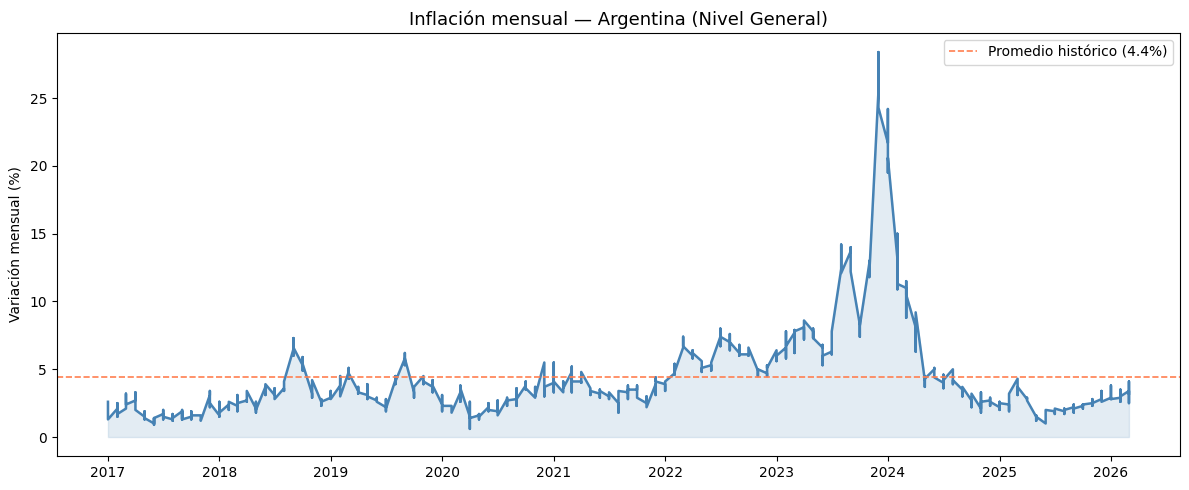

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_arg["Periodo"], df_arg["v_m_IPC"], color='steelblue', linewidth=1.8)

ax.fill_between(
    df_arg["Periodo"],
    df_arg["v_m_IPC"],
    alpha=0.15,
    color='steelblue'
)

ax.axhline(
    y=df_arg["v_m_IPC"].mean(),
    color='coral',
    linestyle='--',
    linewidth=1.2,
    label=f'Promedio histórico ({df_arg["v_m_IPC"].mean():.1f}%)'
)

ax.set_title('Inflación mensual — Argentina (Nivel General)', fontsize=13)
ax.set_ylabel('Variación mensual (%)')
ax.legend()

plt.tight_layout()
plt.show()

In [22]:
def inflacion_anual(serie):
    return ((1 + serie / 100).prod() - 1) * 100


resumen = df_arg.groupby(df_arg["Periodo"].dt.year)["v_m_IPC"].apply(inflacion_anual).round(1)

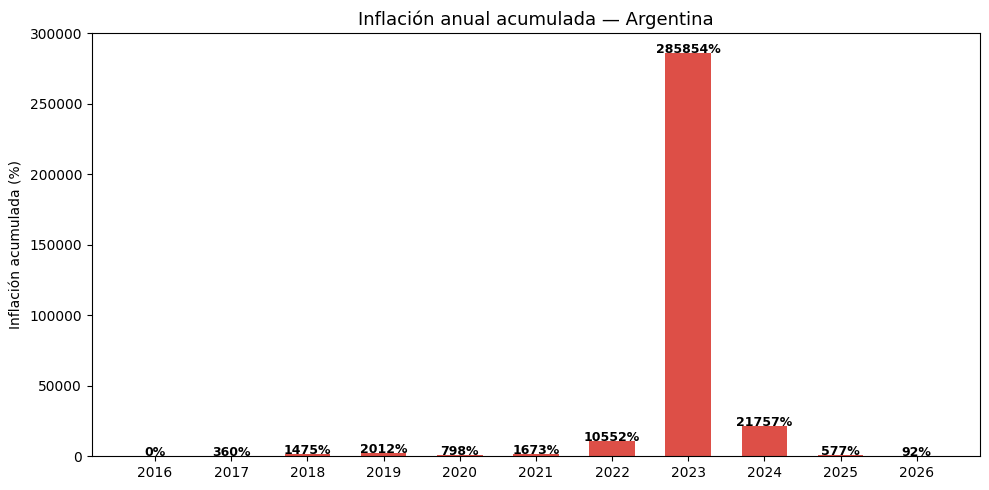

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))

colores = ['#d73027' if x > 50 else '#4575b4' for x in resumen]

barras = ax.bar(
    resumen.index.astype(str),
    resumen.values,
    color=colores,
    alpha=0.85,
    width=0.6
)

for barra, val in zip(barras, resumen.values):
    ax.text(
        barra.get_x() + barra.get_width()/2,
        barra.get_height() + 1,
        f'{val:.0f}%',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

ax.set_title('Inflación anual acumulada — Argentina', fontsize=13)
ax.set_ylabel('Inflación acumulada (%)')

plt.tight_layout()
plt.show()

Largo: 112
NaN restantes: 0


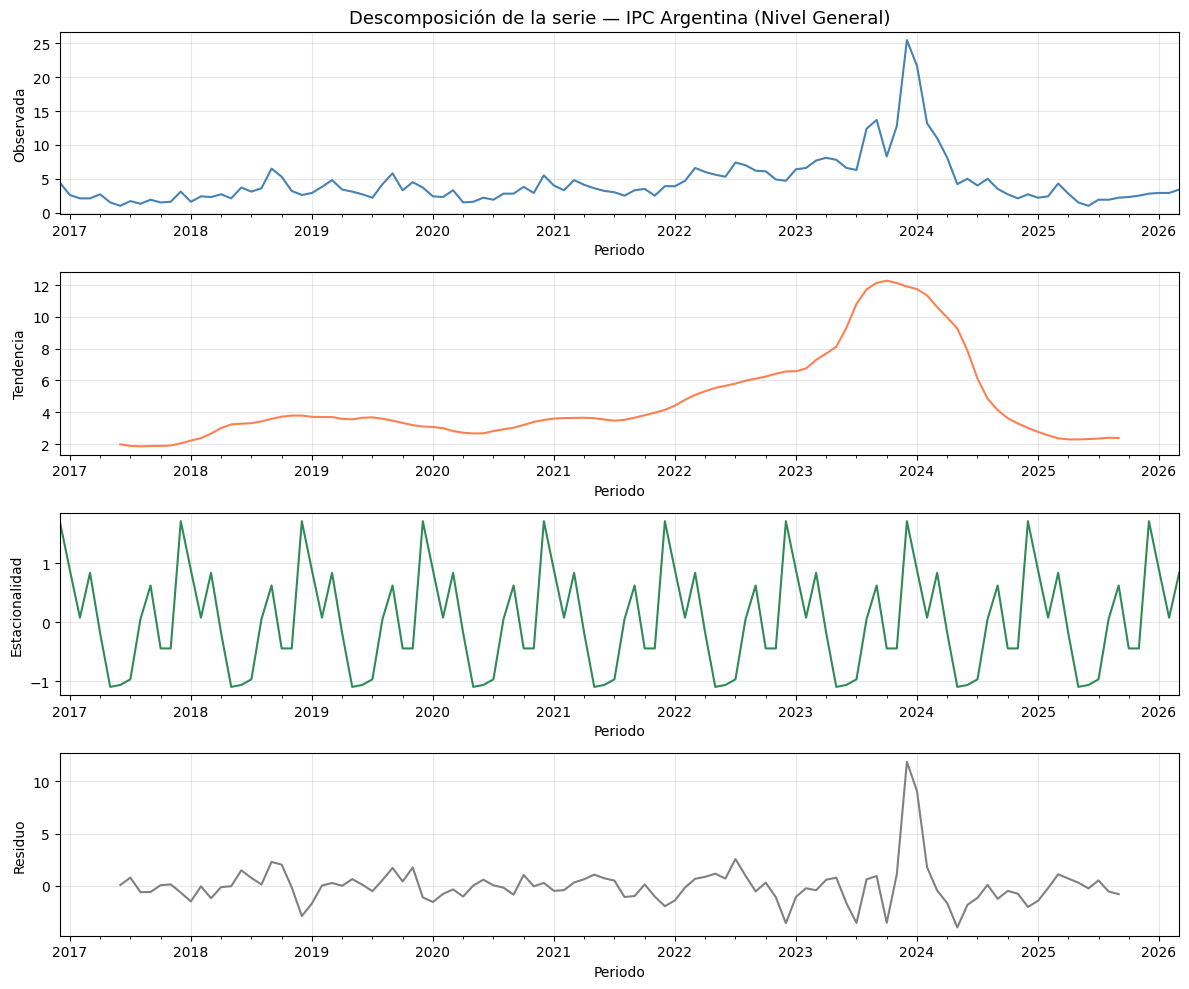

In [24]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Construir serie limpia sin asfreq
df_ts = df_arg.groupby("Periodo")["v_m_IPC"].first()
df_ts = df_ts.sort_index()

# Rellenar el único NaN (dic-2016)
df_ts = df_ts.fillna(df_ts.mean())

# Verificación
print(f"Largo: {len(df_ts)}")
print(f"NaN restantes: {df_ts.isna().sum()}")

decomposition = seasonal_decompose(df_ts, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))

decomposition.observed.plot(ax=axes[0], color='steelblue', linewidth=1.5)
axes[0].set_ylabel("Observada")
axes[0].set_title("Descomposición de la serie — IPC Argentina (Nivel General)", fontsize=13)

decomposition.trend.plot(ax=axes[1], color='coral', linewidth=1.5)
axes[1].set_ylabel("Tendencia")

decomposition.seasonal.plot(ax=axes[2], color='seagreen', linewidth=1.5)
axes[2].set_ylabel("Estacionalidad")

decomposition.resid.plot(ax=axes[3], color='gray', linewidth=1.5)
axes[3].set_ylabel("Residuo")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
#TEST DE DICKEY FULLER (AUMENTADO)
from statsmodels.tsa.stattools import adfuller

resultado_adf = adfuller(df_ts)

print("=" * 45)
print("   TEST DE DICKEY-FULLER AUMENTADO (ADF)")
print("=" * 45)
print(f"  Estadístico ADF : {resultado_adf[0]:.4f}")
print(f"  p-valor         : {resultado_adf[1]:.4f}")
print(f"  Lags utilizados : {resultado_adf[2]}")
print(f"  Observaciones   : {resultado_adf[3]}")
print("\n  Valores críticos:")
for clave, valor in resultado_adf[4].items():
    print(f"    {clave}: {valor:.4f}")
print("=" * 45)

if resultado_adf[1] < 0.05:
    print("  ✔ Serie ESTACIONARIA (se rechaza H0)")
else:
    print("  ✘ Serie NO estacionaria (no se rechaza H0)")
print("=" * 45)

   TEST DE DICKEY-FULLER AUMENTADO (ADF)
  Estadístico ADF : -2.7454
  p-valor         : 0.0665
  Lags utilizados : 3
  Observaciones   : 108

  Valores críticos:
    1%: -3.4924
    5%: -2.8887
    10%: -2.5813
  ✘ Serie NO estacionaria (no se rechaza H0)


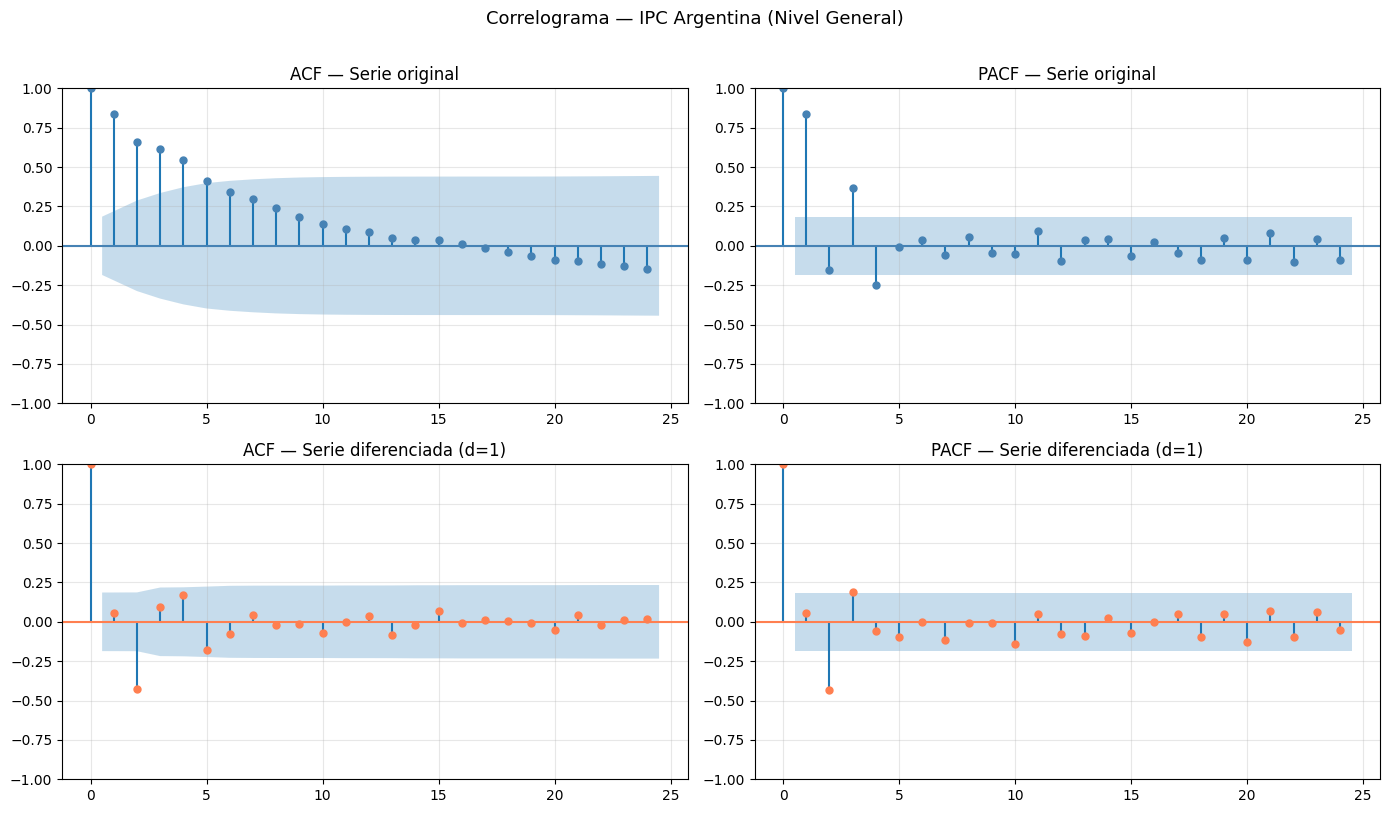

In [26]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Diferenciar la serie para hacerla estacionaria
df_ts_diff = df_ts.diff().dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Serie original
plot_acf(df_ts, lags=24, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title("ACF — Serie original")

plot_pacf(df_ts, lags=24, ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title("PACF — Serie original")

# Serie diferenciada
plot_acf(df_ts_diff, lags=24, ax=axes[1, 0], color='coral')
axes[1, 0].set_title("ACF — Serie diferenciada (d=1)")

plot_pacf(df_ts_diff, lags=24, ax=axes[1, 1], color='coral')
axes[1, 1].set_title("PACF — Serie diferenciada (d=1)")

for ax in axes.flat:
    ax.grid(alpha=0.3)

plt.suptitle("Correlograma — IPC Argentina (Nivel General)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [27]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

# Modelo final seleccionado por menor AIC/BIC — SARIMA(2,1,1)(0,0,1)[12]
modelo = SARIMAX(
    df_ts,
    order=(2, 1, 1),
    seasonal_order=(0, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultado = modelo.fit(disp=False)
print(resultado.summary())

                                     SARIMAX Results                                      
Dep. Variable:                            v_m_IPC   No. Observations:                  112
Model:             SARIMAX(2, 1, 1)x(0, 0, 1, 12)   Log Likelihood                -200.503
Date:                            Fri, 01 May 2026   AIC                            411.007
Time:                                    22:18:05   BIC                            423.880
Sample:                                12-01-2016   HQIC                           416.212
                                     - 03-01-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1912      0.096     -2.000      0.045      -0.379      -0.004
ar.L2         -0.4280      0.053   

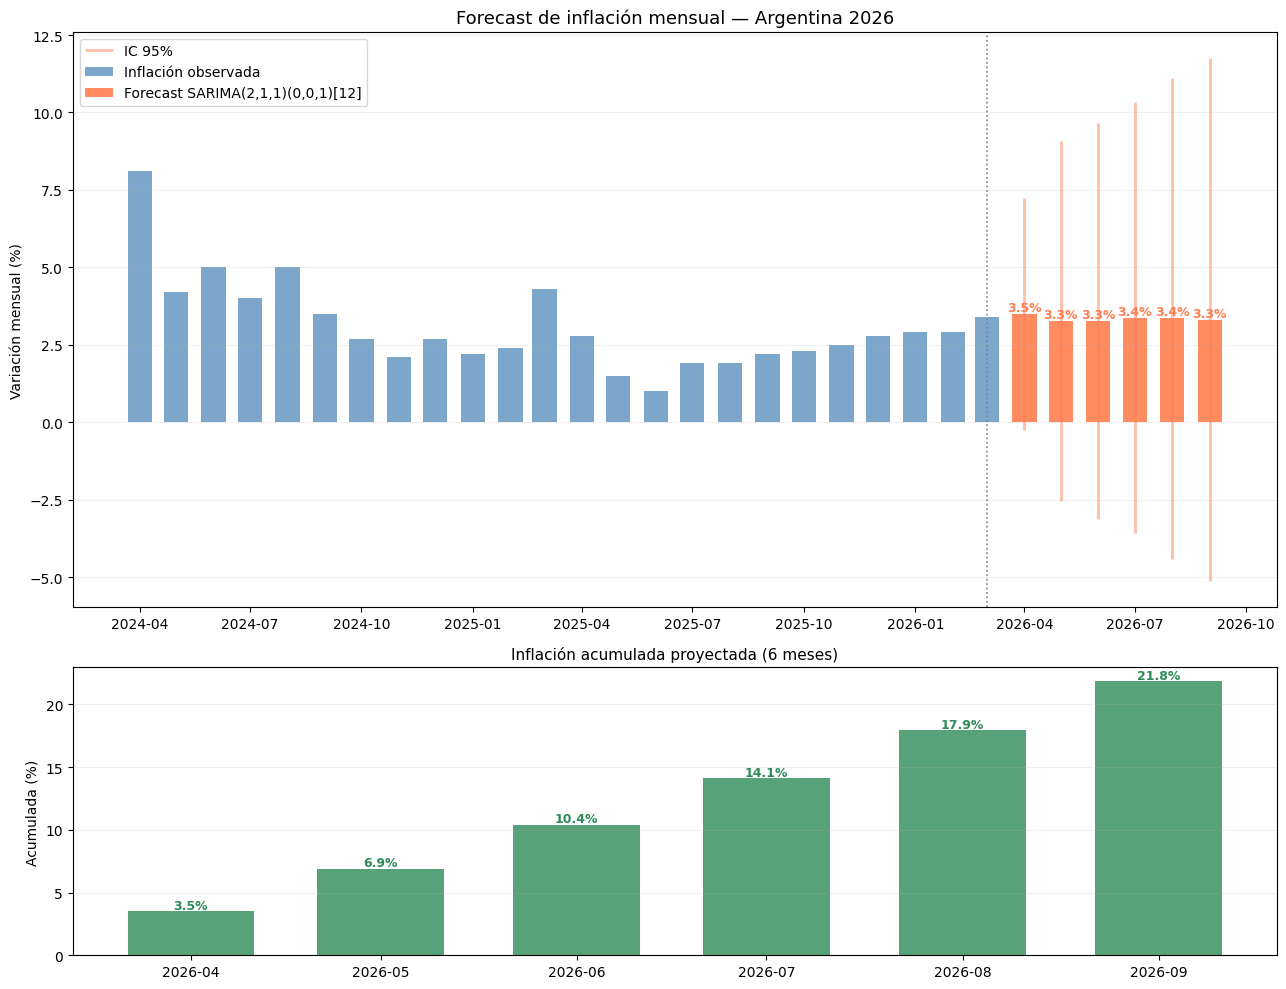

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Forecast 6 meses
forecast = resultado.get_forecast(steps=6)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int(alpha=0.05)

# Últimos 24 meses de historia
historia = df_ts[-24:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 10), gridspec_kw={'height_ratios': [2, 1]})

# --- Gráfico superior: historia + forecast en barras ---
colores_hist = ['steelblue'] * len(historia)
ax1.bar(historia.index, historia.values, width=20, color='steelblue',
        alpha=0.7, label='Inflación observada')

colores_fc = ['coral'] * len(forecast_mean)
bars = ax1.bar(forecast_mean.index, forecast_mean.values, width=20,
               color='coral', alpha=0.9, label='Forecast SARIMA(2,1,1)(0,0,1)[12]')

# Etiquetas sobre las barras del forecast
for bar, val in zip(bars, forecast_mean.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold', color='coral')

# Intervalo de confianza
ax1.vlines(forecast_mean.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
           color='coral', linewidth=2, alpha=0.5, label='IC 95%')

ax1.axvline(x=df_ts.index[-1], color='gray', linestyle=':', linewidth=1.2)
ax1.set_title('Forecast de inflación mensual — Argentina 2026', fontsize=13)
ax1.set_ylabel('Variación mensual (%)')
ax1.legend()
ax1.grid(alpha=0.2, axis='y')

# --- Gráfico inferior: inflación acumulada proyectada ---
acumulada = ((1 + forecast_mean / 100).cumprod() - 1) * 100

ax2.bar(forecast_mean.index, acumulada.values, width=20,
        color='seagreen', alpha=0.8)

for i, (idx, val) in enumerate(zip(acumulada.index, acumulada.values)):
    ax2.text(idx, val + 0.2, f'{val:.1f}%', ha='center',
             fontsize=9, fontweight='bold', color='seagreen')

ax2.set_title('Inflación acumulada proyectada (6 meses)', fontsize=11)
ax2.set_ylabel('Acumulada (%)')
ax2.grid(alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('forecast_inflacion.png', dpi=150, bbox_inches='tight')
plt.show()